In [0]:
from pyspark.sql import SparkSession

In [0]:
spark = SparkSession.builder.appName("Analysis").getOrCreate()

In [0]:
df = spark.read.csv('/FileStore/tables/Copy_of_amazon_data_BDA_1_.csv',inferSchema=True,header=True)

In [0]:
df.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Adj Close: double (nullable = true)
 |-- Volume: integer (nullable = true)
 |-- Daily Return: string (nullable = true)



In [0]:
df.show()

+----------+----+----+----+-----+---------+--------+------------+
|      Date|Open|High| Low|Close|Adj Close|  Volume|Daily Return|
+----------+----+----+----+-----+---------+--------+------------+
|1997-05-15|2.44| 2.5|1.93| 1.96|     1.96|72156000|     -19.66%|
|1997-05-16|1.97|1.98|1.71| 1.73|     1.73|14700000|     -12.17%|
|1997-05-19|1.76|1.77|1.63| 1.71|     1.71| 6106800|      -2.96%|
|1997-05-20|1.73|1.75|1.64| 1.64|     1.64| 5467200|      -5.42%|
|1997-05-21|1.64|1.65|1.38| 1.43|     1.43|18853200|     -12.74%|
|1997-05-22|1.44|1.45|1.31|  1.4|      1.4|11776800|      -2.90%|
|1997-05-23|1.41|1.52|1.33|  1.5|      1.5|15937200|       6.67%|
|1997-05-27|1.51|1.65|1.46| 1.58|     1.58| 8697600|       4.83%|
|1997-05-28|1.63|1.64|1.53| 1.53|     1.53| 4574400|      -5.77%|
|1997-05-29|1.54|1.54|1.48| 1.51|     1.51| 3472800|      -2.36%|
|1997-05-30| 1.5|1.51|1.48|  1.5|      1.5| 2594400|       0.00%|
|1997-06-02|1.51|1.53| 1.5| 1.51|     1.51|  591600|       0.00%|
|1997-06-0

In [0]:
# Import necessary libraries
from pyspark.sql.functions import count, mean, max, min, stddev, corr, when
import matplotlib.pyplot as plt
import pandas as pd


In [0]:
# Summary statistics
df.describe().show()



+-------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+------------+
|summary|             Open|             High|              Low|            Close|        Adj Close|           Volume|Daily Return|
+-------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+------------+
|  count|             6200|             6200|             6200|             6200|             6200|             6200|        6200|
|   mean|541.9347403225811|547.8860112903225|535.3932370967746|541.7921258064523|541.7921258064523|7300664.451612903|        null|
| stddev|889.9342629177642|899.1731336001415| 879.611459774885|889.4029171027925|889.4029171027925|7131785.864883558|        null|
|    min|             1.41|             1.45|             1.31|              1.4|              1.4|           487200|      -0.01%|
|    max|           3744.0|          3773.08|          3696.79|          3731.41|  

In [0]:

# Check for missing values
missing_values = df.select([count(col(c)).alias(c) for c in df.columns])
missing_values.show()


+----+----+----+----+-----+---------+------+------------+
|Date|Open|High| Low|Close|Adj Close|Volume|Daily Return|
+----+----+----+----+-----+---------+------+------------+
|6200|6200|6200|6200| 6200|     6200|  6200|        6200|
+----+----+----+----+-----+---------+------+------------+



In [0]:
# Convert Spark DataFrame to Pandas for visualization
pdf = df.toPandas()

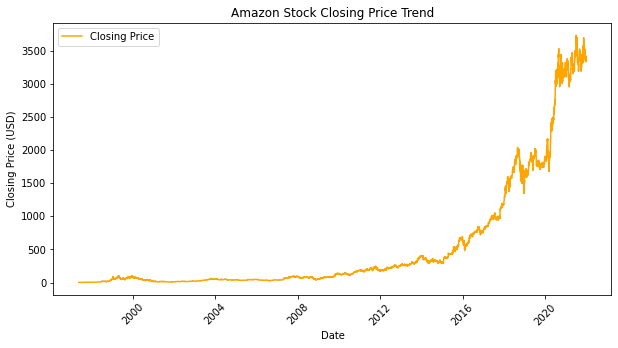

In [0]:

# Plot closing price trend
plt.figure(figsize=(10,5))
plt.plot(pdf['Date'], pdf['Close'], label='Closing Price', color='orange')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.title('Amazon Stock Closing Price Trend')
plt.legend()
plt.xticks(rotation=45)
plt.show()


In [0]:
# Calculate 7-day Moving Average without using Window function
def calculate_moving_average(pdf, column, window_size):
    pdf[f'{window_size}-day Moving Avg'] = pdf[column].rolling(window=window_size).mean()
    return pdf


In [0]:
# Apply moving average calculation
pdf = calculate_moving_average(pdf, 'Close', 7)


In [0]:
# Display first 10 rows with moving average
print(pdf[['Date', 'Close', '7-day Moving Avg']].head(10))


         Date  Close  7-day Moving Avg
0  1997-05-15   1.96               NaN
1  1997-05-16   1.73               NaN
2  1997-05-19   1.71               NaN
3  1997-05-20   1.64               NaN
4  1997-05-21   1.43               NaN
5  1997-05-22   1.40               NaN
6  1997-05-23   1.50          1.624286
7  1997-05-27   1.58          1.570000
8  1997-05-28   1.53          1.541429
9  1997-05-29   1.51          1.512857


In [0]:
# Calculate standard deviation of closing prices
std_dev = df.select(stddev("Close")).collect()[0][0]
print(f"Standard Deviation of Closing Prices: {std_dev}")


Standard Deviation of Closing Prices: 889.4029171027925


In [0]:

# Analyze Open, High, and Low prices
open_mean = df.select(mean("Open")).collect()[0][0]
high_max = df.select(max("High")).collect()[0][0]
low_min = df.select(min("Low")).collect()[0][0]

print(f"Average Opening Price: {open_mean}")
print(f"Highest Price Recorded: {high_max}")
print(f"Lowest Price Recorded: {low_min}")



Average Opening Price: 541.9347403225811
Highest Price Recorded: 3773.08
Lowest Price Recorded: 1.31


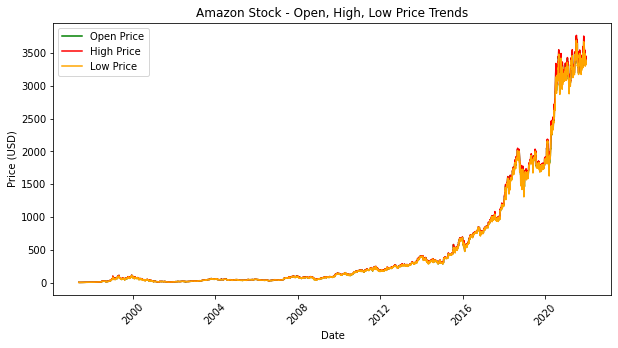

In [0]:

# Plot Open, High, and Low prices
plt.figure(figsize=(10,5))
plt.plot(pdf['Date'], pdf['Open'], label='Open Price', color='green')
plt.plot(pdf['Date'], pdf['High'], label='High Price', color='red')
plt.plot(pdf['Date'], pdf['Low'], label='Low Price', color='orange')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('Amazon Stock - Open, High, Low Price Trends')
plt.legend()
plt.xticks(rotation=45)
plt.show()



In [0]:
#Price Volatility Analysis
df = df.withColumn("Price Range", col("High") - col("Low"))
df.select("Date", "Price Range").orderBy("Price Range", ascending=False).show(10)


+----------+------------------+
|      Date|       Price Range|
+----------+------------------+
|2020-07-13| 275.9000000000001|
|2020-09-04| 270.3699999999999|
|2020-10-16|239.65999999999985|
|2020-07-20|207.34000000000015|
|2020-09-03|185.40999999999985|
|2020-09-10| 179.3399999999997|
|2020-07-14| 177.3800000000001|
|2020-11-09|176.88999999999987|
|2018-10-29|            170.74|
|2020-03-17|168.53999999999996|
+----------+------------------+
only showing top 10 rows



In [0]:
#Trend Analysis
price_trend = df.select(corr("Open", "Close")).collect()[0][0]
print(f"Correlation between Open and Close prices: {price_trend}")


Correlation between Open and Close prices: 0.9998406951214301


In [0]:

#Intraday Trading Patterns
df = df.withColumn("Intraday Change", col("Close") - col("Open"))
df.select("Date", "Intraday Change").show(10)


+----------+--------------------+
|      Date|     Intraday Change|
+----------+--------------------+
|1997-05-15|               -0.48|
|1997-05-16|               -0.24|
|1997-05-19|-0.05000000000000...|
|1997-05-20|-0.09000000000000008|
|1997-05-21|-0.20999999999999996|
|1997-05-22|-0.04000000000000...|
|1997-05-23| 0.09000000000000008|
|1997-05-27| 0.07000000000000006|
|1997-05-28|-0.09999999999999987|
|1997-05-29|-0.03000000000000...|
+----------+--------------------+
only showing top 10 rows



In [0]:
#Monthly Average Price Analysis
from pyspark.sql.functions import month
df = df.withColumn("Month", month("Date"))
monthly_avg = df.groupBy("Month").agg(mean("Close").alias("Avg Close"))
monthly_avg.show()

+-----+-----------------+
|Month|        Avg Close|
+-----+-----------------+
|   12| 583.259640831758|
|    1|473.7759587628865|
|    6|535.8631962616821|
|    3|485.5012737642585|
|    5|518.6276982591875|
|    9|583.3522682445757|
|    4|522.3072837022133|
|    8|566.7661050724635|
|    7|577.8395094339622|
|   10|570.4052536231885|
|   11|583.8798823529412|
|    2|485.8606521739129|
+-----+-----------------+



In [0]:
#Impact of Volume on Price Movement
volume_correlation = df.select(corr("Volume", "Close")).collect()[0][0]
print(f"Correlation between Volume and Close price: {volume_correlation}")


Correlation between Volume and Close price: -0.24320747115489183
